# Phase I — Prostate Histopathology Patch Classification

5-class patch classification (Stroma, Normal, G3, G4, G5) on SetA and SetB cohorts.
EfficientNet-B2 pretrained on ImageNet, fully fine-tuned. Primary metric: Macro F1.

## 0 · Environment Setup

In [1]:
import os
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)

warnings.filterwarnings('ignore')

print(f'PyTorch  {torch.__version__}')
print(f'CUDA available : {torch.cuda.is_available()}')
print(f'MPS  available : {torch.backends.mps.is_available()}')

PyTorch  2.11.0
CUDA available : False
MPS  available : True


In [2]:
# ── Reproducibility ────────────────────────────────────────────────────────────
# Setting the same seed everywhere means that random operations — weight
# initialisation, data shuffling, augmentation — produce the same outcome
# each time the notebook is re-run from scratch.

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything(42)
print('Seeds fixed at 42.')

# ── Device ─────────────────────────────────────────────────────────────────────
device = (
    torch.device('cuda') if torch.cuda.is_available() else
    torch.device('mps')  if torch.backends.mps.is_available() else
    torch.device('cpu')
)
print(f'Using device: {device}')

Seeds fixed at 42.
Using device: mps


## 1 · Configuration

Set `domain` to `'A'` then run all cells. Change to `'B'` and run again for the second cohort.

In [3]:
# ── Master configuration ───────────────────────────────────────────────────────
# Change ONLY `domain` to switch between SetA and SetB.
# Every path and output directory adjusts automatically.

CONFIG = {
    # ── Experiment identity
    'domain'       : 'A',        # 'A' or 'B'  — run once per domain; both outputs are independent

    # ── Data
    'data_root'    : 'Data',
    'image_size'   : 224,        # resize target; EfficientNet-B2 native is 260px
    'val_fraction' : 0.15,       # 15 % of the train folder becomes internal validation
    'seed'         : 42,

    # ── DataLoader
    'batch_size'   : 32,
    # num_workers must be 0 in notebooks on macOS.
    # PyTorch uses 'spawn' to create worker processes, and spawned processes
    # cannot import classes defined in a notebook cell (__main__ has no file).
    # On Linux or in a plain Python script, you can safely raise this to 4+.
    'num_workers'  : 0,

    # ── Training
    'epochs'         : 60,
    'lr'             : 3e-4,     # peak learning rate reached after warmup
    'weight_decay'   : 1e-4,
    'warmup_epochs'  : 5,        # LR rises linearly from ~0 → lr over these epochs
    'patience'       : 12,       # early stopping: halt if val Macro F1 stalls this long
    'grad_clip'      : 1.0,      # max gradient norm; prevents unstable updates
    'num_classes'    : 5,
}

# ── Derived paths (auto-populated, do not edit) ────────────────────────────────
d = CONFIG['domain']
CONFIG['train_dir']  = os.path.join(CONFIG['data_root'], f'Set{d}', f'251_Train_{d}')
CONFIG['test_dir']   = os.path.join(CONFIG['data_root'], f'Set{d}', f'251_Test_{d}')
CONFIG['output_dir'] = os.path.join('outputs', f'set{d.lower()}')

# ── Class label map (identical for both domains) ───────────────────────────────
CLASS_NAMES = ['Stroma', 'Normal', 'G3', 'G4', 'G5']
CLASS_MAP   = {name: idx for idx, name in enumerate(CLASS_NAMES)}

# ── Create output folder tree ─────────────────────────────────────────────────
for sub in ['splits', 'checkpoints', 'logs', 'reports']:
    os.makedirs(os.path.join(CONFIG['output_dir'], sub), exist_ok=True)

print(f"Domain    : Set{d}")
print(f"Train dir : {CONFIG['train_dir']}")
print(f"Test dir  : {CONFIG['test_dir']}")
print(f"Output    : {CONFIG['output_dir']}")

Domain    : SetB
Train dir : Data/SetB/251_Train_B
Test dir  : Data/SetB/251_Test_B
Output    : outputs/setb


## 2 · Dataset Indexing

Walk train and test directories on disk; one row per patch.

In [4]:
def build_index(train_dir: str, test_dir: str, class_map: dict) -> pd.DataFrame:
    """
    Walk train and test directories. For each .tif file record:
      path       - full relative path to the patch
      class_name - tissue type inferred from parent folder name
      class_idx  - integer label (0-4)
      split      - 'trainpool' (later refined) or 'test'
    """
    records = []
    for split_tag, folder in [('trainpool', train_dir), ('test', test_dir)]:
        for cls_name, cls_idx in class_map.items():
            cls_folder = os.path.join(folder, cls_name)
            if not os.path.isdir(cls_folder):
                print(f'  [warn] folder not found: {cls_folder}')
                continue
            for fname in sorted(os.listdir(cls_folder)):
                if fname.lower().endswith('.tif'):
                    records.append({
                        'path'      : os.path.join(cls_folder, fname),
                        'class_name': cls_name,
                        'class_idx' : cls_idx,
                        'split'     : split_tag,
                    })
    return pd.DataFrame(records)


index_df = build_index(CONFIG['train_dir'], CONFIG['test_dir'], CLASS_MAP)

# Show raw counts before the val split
print(f'Total patches indexed from disk: {len(index_df)}\n')
count_tbl = (
    index_df
    .groupby(['split', 'class_name'])
    .size()
    .unstack(fill_value=0)
    [CLASS_NAMES]
)
count_tbl['Total'] = count_tbl.sum(axis=1)
print(count_tbl)

Total patches indexed from disk: 4700

class_name  Stroma  Normal   G3   G4   G5  Total
split                                           
test           200     200  200  200  200   1000
trainpool      800     800  800  800  500   3700


## 3 · Validation Split

Stratified 15% of train patches per class; test set stays sealed.

In [5]:
def stratified_val_split(
    df: pd.DataFrame,
    val_fraction: float,
    seed: int,
) -> pd.DataFrame:
    """
    Split the trainpool rows into 'train' and 'val' subsets.
    Test rows are passed through unchanged.
    Uses StratifiedShuffleSplit so every class is proportionally represented.
    """
    pool = df[df['split'] == 'trainpool'].copy()
    test = df[df['split'] == 'test'].copy()

    sss = StratifiedShuffleSplit(
        n_splits=1, test_size=val_fraction, random_state=seed
    )
    train_idx, val_idx = next(sss.split(pool.index, pool['class_idx']))

    pool.iloc[train_idx, pool.columns.get_loc('split')] = 'train'
    pool.iloc[val_idx,   pool.columns.get_loc('split')] = 'val'

    return pd.concat([pool, test], ignore_index=True)


index_df = stratified_val_split(index_df, CONFIG['val_fraction'], CONFIG['seed'])

# Save to disk — this CSV is the reference for all future steps
split_csv = os.path.join(CONFIG['output_dir'], 'splits', f"index_{CONFIG['domain']}.csv")
index_df.to_csv(split_csv, index=False)

# Pretty summary table
summary = (
    index_df
    .groupby(['split', 'class_name'])
    .size()
    .unstack(fill_value=0)
    [CLASS_NAMES]
    .reindex(['train', 'val', 'test'])
)
summary['Total'] = summary.sum(axis=1)
print(summary)
print(f'\nSplit index saved → {split_csv}')

class_name  Stroma  Normal   G3   G4   G5  Total
split                                           
train          680     680  680  680  425   3145
val            120     120  120  120   75    555
test           200     200  200  200  200   1000

Split index saved → outputs/setb/splits/index_B.csv


## 4 · Data Verification

Check for split overlap, image geometry, and pixel range after normalisation.

In [6]:
# ── 1. No leakage between splits ───────────────────────────────────────────────
train_paths = set(index_df[index_df['split'] == 'train']['path'])
val_paths   = set(index_df[index_df['split'] == 'val'  ]['path'])
test_paths  = set(index_df[index_df['split'] == 'test' ]['path'])

assert len(train_paths & val_paths)  == 0, 'LEAK: train ∩ val is not empty'
assert len(train_paths & test_paths) == 0, 'LEAK: train ∩ test is not empty'
assert len(val_paths   & test_paths) == 0, 'LEAK: val ∩ test is not empty'
print('✓  No path overlap between train / val / test.')

# ── 2. Image geometry check (5 patches per class) ─────────────────────────────
print('\nSpot-checking image dimensions ...')
for cls_name in CLASS_NAMES:
    rows = index_df[index_df['class_name'] == cls_name].sample(5, random_state=0)
    for _, row in rows.iterrows():
        img = Image.open(row['path']).convert('RGB')
        assert img.size == (251, 251), f'Unexpected size {img.size} in {row["path"]}'
print('✓  All sampled images are 251 × 251 RGB.')

# ── 3. Normalised pixel range ──────────────────────────────────────────────────
# ImageNet normalisation centres H&E patches differently from natural images,
# but the pretrained model adapts during fine-tuning.  The range check confirms
# the transform pipeline is wired correctly.
quick_t = T.Compose([
    T.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
sample_rows = index_df[index_df['split'] == 'train'].sample(30, random_state=0)
tensors = torch.stack([
    quick_t(Image.open(r['path']).convert('RGB'))
    for _, r in sample_rows.iterrows()
])
print(f'\nNormalised pixel range — min: {tensors.min():.3f}   max: {tensors.max():.3f}')
print('(Expected roughly −2.5 to +2.5 for ImageNet normalisation on H&E patches)')

✓  No path overlap between train / val / test.

Spot-checking image dimensions ...
✓  All sampled images are 251 × 251 RGB.

Normalised pixel range — min: -1.581   max: 2.483
(Expected roughly −2.5 to +2.5 for ImageNet normalisation on H&E patches)


## 5 · Transforms & Augmentation

Training: horizontal/vertical flip, random rotation, colour jitter.
Val/test: resize to 224 × 224 and normalise to ImageNet statistics.

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def get_transforms(split: str, image_size: int = 224) -> T.Compose:
    """
    Returns the appropriate torchvision transform pipeline for a given split.
    'train'       → augmented
    'val' / 'test' → clean (resize + normalise only)
    """
    if split == 'train':
        return T.Compose([
            T.Resize((image_size + 16, image_size + 16)),   # slight oversize before crop
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.5),
            T.RandomRotation(degrees=90),
            T.ColorJitter(
                brightness=0.15, contrast=0.15,
                saturation=0.10, hue=0.03
            ),
            T.RandomResizedCrop(
                image_size,
                scale=(0.85, 1.0),
                ratio=(0.95, 1.05),
                interpolation=T.InterpolationMode.BICUBIC,
            ),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
    else:  # val or test
        return T.Compose([
            T.Resize(
                (image_size, image_size),
                interpolation=T.InterpolationMode.BICUBIC,
            ),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])


print('Train transform:')
print(get_transforms('train', CONFIG['image_size']))
print('\nVal/Test transform:')
print(get_transforms('val', CONFIG['image_size']))

Train transform:
Compose(
    Resize(size=(240, 240), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-90.0, 90.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.9, 1.1), hue=(-0.03, 0.03))
    RandomResizedCrop(size=(224, 224), scale=(0.85, 1.0), ratio=(0.95, 1.05), interpolation=bicubic, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Val/Test transform:
Compose(
    Resize(size=(224, 224), interpolation=bicubic, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


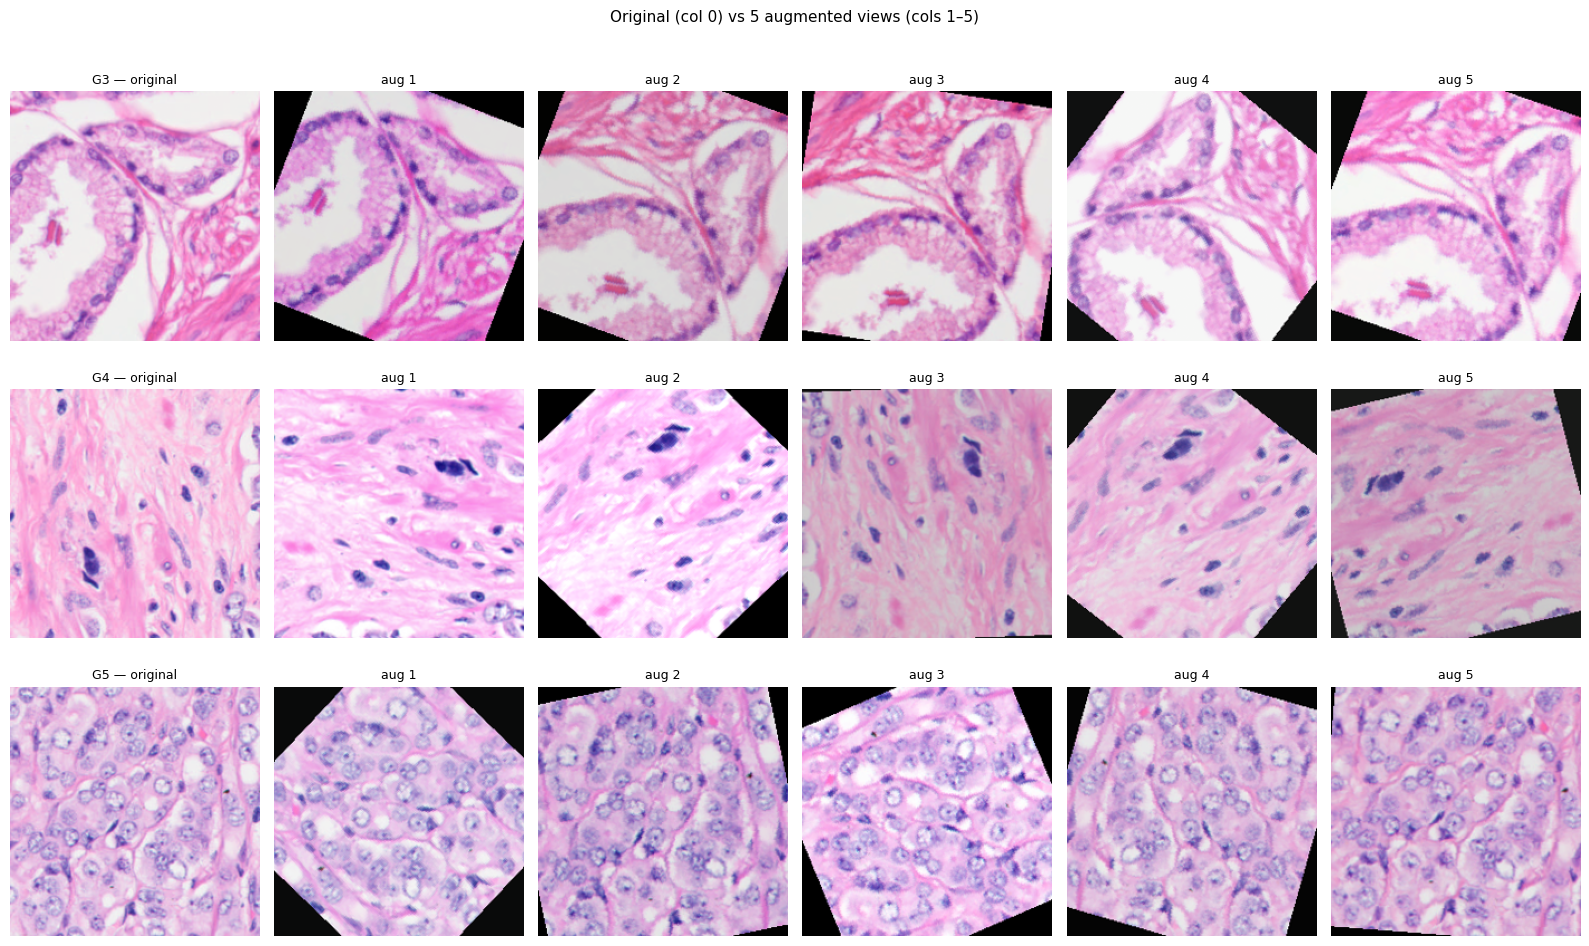

In [8]:
# ── Visualise augmentation effect ──────────────────────────────────────────────
# Shows one original patch alongside five independently augmented versions
# for three randomly sampled classes.  Confirms the augmentation is realistic
# (staining variation is mild; tissue structure remains recognisable).

unnorm = T.Compose([
    T.Normalize(
        mean=[-m / s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
        std =[1.0 / s for s in IMAGENET_STD],
    )
])

train_t = get_transforms('train', CONFIG['image_size'])
val_t   = get_transforms('val',   CONFIG['image_size'])

vis_classes = ['G3', 'G4', 'G5']
fig, axes = plt.subplots(len(vis_classes), 6, figsize=(16, 3.2 * len(vis_classes)))
fig.suptitle('Original (col 0) vs 5 augmented views (cols 1–5)', fontsize=11, y=1.01)

for row_i, cls_name in enumerate(vis_classes):
    path = (
        index_df[index_df['class_name'] == cls_name]
        .sample(1, random_state=row_i)['path']
        .values[0]
    )
    img = Image.open(path).convert('RGB')

    orig_t = unnorm(val_t(img)).permute(1, 2, 0).clamp(0, 1).numpy()
    axes[row_i, 0].imshow(orig_t)
    axes[row_i, 0].set_title(f'{cls_name} — original', fontsize=9)
    axes[row_i, 0].axis('off')

    for col_i in range(1, 6):
        aug_t = unnorm(train_t(img)).permute(1, 2, 0).clamp(0, 1).numpy()
        axes[row_i, col_i].imshow(aug_t)
        axes[row_i, col_i].set_title(f'aug {col_i}', fontsize=9)
        axes[row_i, col_i].axis('off')

plt.tight_layout()
plt.show()

## 6 · Dataset & DataLoaders

`HistoDataset` reads patches on-the-fly via PIL; `get_dataloaders` wraps all three splits.

In [9]:
import sys

class HistoDataset(Dataset):
    """
    Reads H&E patches from disk one at a time.
    Labels are derived from the 'class_idx' column of the index DataFrame.
    """

    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, int(row['class_idx'])


def get_dataloaders(df: pd.DataFrame, config: dict) -> dict:
    # On macOS, PyTorch spawns worker processes using 'spawn' (not 'fork').
    # Spawned processes can't unpickle classes defined in a notebook cell,
    # so num_workers must be 0 here regardless of what CONFIG says.
    safe_workers = 0 if sys.platform == 'darwin' else config['num_workers']

    splits = {
        'train': df[df['split'] == 'train'],
        'val'  : df[df['split'] == 'val'],
        'test' : df[df['split'] == 'test'],
    }
    loaders = {}
    for name, subset in splits.items():
        ds = HistoDataset(
            subset,
            transform=get_transforms(name, config['image_size']),
        )
        loaders[name] = DataLoader(
            ds,
            batch_size  = config['batch_size'],
            shuffle     = (name == 'train'),
            num_workers = safe_workers,
            pin_memory  = False,   # pin_memory=True has no effect with num_workers=0
            drop_last   = (name == 'train'),
        )
    return loaders


loaders = get_dataloaders(index_df, CONFIG)

print('DataLoader summary:')
for name, ldr in loaders.items():
    print(f'  {name:5s}  {len(ldr.dataset):5d} patches  |  {len(ldr):4d} batches')

DataLoader summary:
  train   3145 patches  |    98 batches
  val      555 patches  |    18 batches
  test    1000 patches  |    32 batches


## 7 · Model Architecture

EfficientNet-B2 pretrained on ImageNet, final FC replaced with a 5-class head.

In [10]:
def build_model(num_classes: int = 5) -> nn.Module:
    """
    EfficientNet-B2 with an ImageNet-pretrained backbone.
    The final linear layer is replaced to output `num_classes` logits.
    All parameters remain trainable (full fine-tuning).
    """
    model = models.efficientnet_b2(
        weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1
    )
    in_features = model.classifier[1].in_features   # 1408 for EfficientNet-B2
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


model = build_model(CONFIG['num_classes']).to(device)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_p:,}')
print(f'Trainable parameters : {trainable_p:,}')

# ── Sanity-check: one forward pass before the training loop ───────────────────
dummy = torch.randn(2, 3, CONFIG['image_size'], CONFIG['image_size']).to(device)
with torch.no_grad():
    out = model(dummy)
assert out.shape == (2, CONFIG['num_classes']), f'Unexpected output shape: {out.shape}'
print(f'Forward pass check   : output shape {tuple(out.shape)}  ✓')

Total parameters     : 7,708,039
Trainable parameters : 7,708,039
Forward pass check   : output shape (2, 5)  ✓


## 8 · Loss · Optimizer · Scheduler

Weighted CrossEntropyLoss (inverse-frequency weights; G5 has fewer training patches).
AdamW with weight decay 1e-4. Warmup + cosine annealing scheduler.

In [11]:
# ── Class weights from training split only ─────────────────────────────────────
# Never compute weights from val or test — that would be a form of leakage.

def compute_class_weights(df: pd.DataFrame, num_classes: int) -> torch.Tensor:
    train_labels = df[df['split'] == 'train']['class_idx'].values
    counts       = np.bincount(train_labels, minlength=num_classes).astype(float)
    total        = len(train_labels)
    weights      = total / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)


class_weights = compute_class_weights(index_df, CONFIG['num_classes'])
print('Class weights (higher = more emphasis during training):')
for name, w in zip(CLASS_NAMES, class_weights):
    print(f'  {name:8s}  {w:.4f}')

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

Class weights (higher = more emphasis during training):
  Stroma    0.9250
  Normal    0.9250
  G3        0.9250
  G4        0.9250
  G5        1.4800


In [12]:
# ── Optimizer ─────────────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = CONFIG['lr'],
    weight_decay = CONFIG['weight_decay'],
)

# ── LR Scheduler: linear warmup + cosine decay ────────────────────────────────
# The scheduler steps every optimiser step (not every epoch) for smooth LR curves.
steps_per_epoch = len(loaders['train'])
total_steps     = CONFIG['epochs'] * steps_per_epoch
warmup_steps    = CONFIG['warmup_epochs'] * steps_per_epoch


def lr_lambda(current_step: int) -> float:
    """LR multiplier: ramps up linearly, then decays via cosine."""
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    progress = float(current_step - warmup_steps) / float(
        max(1, total_steps - warmup_steps)
    )
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f'Steps per epoch : {steps_per_epoch}')
print(f'Warmup steps    : {warmup_steps}')
print(f'Total steps     : {total_steps}')

Steps per epoch : 98
Warmup steps    : 490
Total steps     : 5880


In [13]:
# ── Early Stopping ────────────────────────────────────────────────────────────
# Monitors val Macro F1.  If it doesn't improve for `patience` consecutive epochs,
# `triggered` is set to True and the training loop breaks.
# The best checkpoint is always saved the moment an improvement is detected.

class EarlyStopping:
    def __init__(self, patience: int, mode: str = 'max'):
        self.patience  = patience
        self.mode      = mode
        self.best      = -float('inf') if mode == 'max' else float('inf')
        self.counter   = 0
        self.triggered = False

    def step(self, value: float) -> bool:
        """Returns True if this is a new best (caller should save checkpoint)."""
        improved = (
            (self.mode == 'max' and value > self.best) or
            (self.mode == 'min' and value < self.best)
        )
        if improved:
            self.best    = value
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.triggered = True
        return improved


stopper = EarlyStopping(patience=CONFIG['patience'], mode='max')
print(f'Early stopping active — patience: {CONFIG["patience"]} epochs on val Macro F1')

Early stopping active — patience: 12 epochs on val Macro F1


## 9 · Training

Standard train/val loop with early stopping on val Macro F1.
Best checkpoint saved when val F1 improves.

In [14]:
def train_one_epoch(
    model, loader, optimizer, scheduler, criterion, device, grad_clip
):
    """
    One full pass through the training DataLoader.
    Returns (average_loss, accuracy) over all training patches.
    """
    model.train()
    running_loss = 0.0
    correct = total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        # clip gradient norm — prevents a hard batch from causing a destructive update
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

        optimizer.step()
        scheduler.step()   # step-level LR update (not epoch-level)

        running_loss += loss.item() * images.size(0)
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += images.size(0)

    return running_loss / total, correct / total


def validate(model, loader, criterion, device):
    """
    Evaluate on the validation split.
    Returns (average_loss, accuracy, macro_f1).
    Macro F1 is the primary model-selection metric — it weights all five classes equally.
    """
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)
            running_loss  += loss.item() * images.size(0)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    n        = len(all_labels)
    avg_loss = running_loss / n
    accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / n
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return avg_loss, accuracy, macro_f1


print('train_one_epoch and validate defined.')

train_one_epoch and validate defined.


In [15]:
# ── Training loop ────────────────────────────────────────────────────────────
ckpt_path = os.path.join(CONFIG['output_dir'], 'checkpoints', 'best_model.pth')
log_path  = os.path.join(CONFIG['output_dir'], 'logs', 'training_log.csv')

if os.path.exists(ckpt_path):
    print(f'Checkpoint found at {ckpt_path} — skipping training.')
    ckpt = torch.load(ckpt_path, map_location=device)
    history = pd.read_csv(log_path).to_dict('list') if os.path.exists(log_path) else {}
else:
    log_path  = os.path.join(CONFIG['output_dir'], 'logs', 'training_log.csv')
    
    history = {
        'epoch'      : [],
        'train_loss' : [],
        'val_loss'   : [],
        'val_acc'    : [],
        'val_f1'     : [],
        'lr'         : [],
    }
    
    print(f'{'Epoch':>6}  {'TrnLoss':>8}  {'ValLoss':>8}  {'ValAcc':>7}  {'ValF1':>7}  Status')
    print('─' * 72)
    
    for epoch in range(1, CONFIG['epochs'] + 1):
    
        train_loss, train_acc = train_one_epoch(
            model, loaders['train'], optimizer, scheduler,
            criterion, device, CONFIG['grad_clip'],
        )
        val_loss, val_acc, val_f1 = validate(model, loaders['val'], criterion, device)
        current_lr = optimizer.param_groups[0]['lr']
    
        history['epoch'].append(epoch)
        history['train_loss'].append(round(train_loss, 5))
        history['val_loss'].append(round(val_loss, 5))
        history['val_acc'].append(round(val_acc, 5))
        history['val_f1'].append(round(val_f1, 5))
        history['lr'].append(round(current_lr, 8))
    
        improved = stopper.step(val_f1)
        if improved:
            torch.save({
                'epoch'           : epoch,
                'model_state_dict': model.state_dict(),
                'val_macro_f1'    : val_f1,
                'config'          : CONFIG,
            }, ckpt_path)
            status = '✓ saved'
        else:
            status = f'patience {stopper.counter}/{stopper.patience}'
    
        print(
            f'{epoch:6d}  {train_loss:8.4f}  {val_loss:8.4f}  '
            f'{val_acc:7.4f}  {val_f1:7.4f}  {status}'
        )
    
        if stopper.triggered:
            print(f'\nEarly stopping triggered at epoch {epoch}. '
                  f'Best Val Macro F1: {stopper.best:.4f}')
            break
    
    # Persist training log
    pd.DataFrame(history).to_csv(log_path, index=False)
    print(f'\nTraining complete.  Log → {log_path}')
    print(f'Best checkpoint    → {ckpt_path}')

 Epoch   TrnLoss   ValLoss   ValAcc    ValF1  Status
────────────────────────────────────────────────────────────────────────
     1    1.4274    0.9765   0.7676   0.7574  ✓ saved
     2    0.6551    0.3569   0.8793   0.8721  ✓ saved
     3    0.3719    0.2806   0.8991   0.8924  ✓ saved
     4    0.3239    0.2812   0.9027   0.8968  ✓ saved
     5    0.2695    0.3365   0.9063   0.8988  ✓ saved
     6    0.2550    0.2155   0.9279   0.9259  ✓ saved
     7    0.2219    0.2607   0.9045   0.8986  patience 1/12
     8    0.2221    0.3716   0.8829   0.8789  patience 2/12
     9    0.1754    0.2140   0.9369   0.9375  ✓ saved
    10    0.1830    0.1904   0.9261   0.9261  patience 1/12
    11    0.1588    0.2152   0.9261   0.9230  patience 2/12
    12    0.1576    0.1913   0.9315   0.9286  patience 3/12
    13    0.1170    0.2492   0.9243   0.9220  patience 4/12
    14    0.1319    0.1871   0.9315   0.9282  patience 5/12
    15    0.0975    0.2350   0.9405   0.9379  ✓ saved
    16    0.1055    0.

## 10 · Training Curves

Train/val loss and val Macro F1 per epoch.

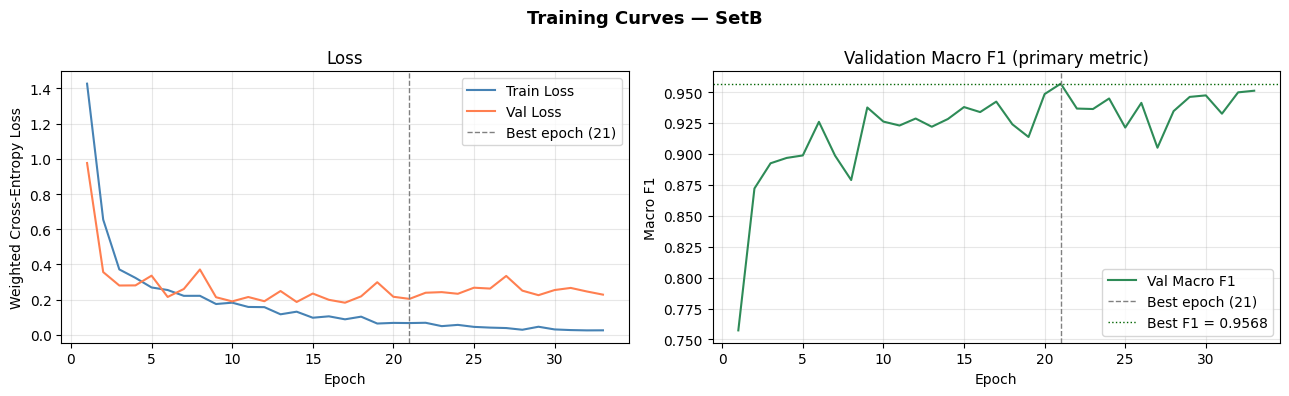

Saved → outputs/setb/reports/training_curves.png


In [16]:
log_df  = pd.DataFrame(history)
best_ep = log_df.loc[log_df['val_f1'].idxmax(), 'epoch']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    f'Training Curves — Set{CONFIG["domain"]}',
    fontsize=13, fontweight='bold',
)

# ── Loss ──────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(log_df['epoch'], log_df['train_loss'],
        label='Train Loss', color='steelblue', linewidth=1.5)
ax.plot(log_df['epoch'], log_df['val_loss'],
        label='Val Loss', color='coral', linewidth=1.5)
ax.axvline(best_ep, linestyle='--', color='grey', linewidth=1,
           label=f'Best epoch ({best_ep})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted Cross-Entropy Loss')
ax.set_title('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Val Macro F1 ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(log_df['epoch'], log_df['val_f1'],
        color='seagreen', linewidth=1.5, label='Val Macro F1')
ax.axvline(best_ep, linestyle='--', color='grey', linewidth=1,
           label=f'Best epoch ({best_ep})')
ax.axhline(stopper.best, linestyle=':', color='darkgreen', linewidth=1,
           label=f'Best F1 = {stopper.best:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Macro F1')
ax.set_title('Validation Macro F1 (primary metric)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
curves_path = os.path.join(CONFIG['output_dir'], 'reports', 'training_curves.png')
plt.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {curves_path}')

## 11 · Test Set Evaluation

Load best checkpoint, run inference on sealed test set, compute all metrics.

In [17]:
# ── Load best checkpoint ───────────────────────────────────────────────────────
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded checkpoint from epoch {ckpt['epoch']}  "
      f"(val Macro F1 = {ckpt['val_macro_f1']:.4f})")

# ── Inference ─────────────────────────────────────────────────────────────────
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in loaders['test']:
        images      = images.to(device)
        outputs     = model(images)
        probs       = F.softmax(outputs, dim=1)
        preds       = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
print(f'Inference complete — {len(all_labels)} test patches.')

Loaded checkpoint from epoch 21  (val Macro F1 = 0.9568)
Inference complete — 1000 test patches.


In [ ]:
# ── Per-class specificity (one-vs-rest binary decomposition) ───────────────────
def per_class_specificity(y_true, y_pred, num_classes):
    specs = []
    for c in range(num_classes):
        tn = ((y_true != c) & (y_pred != c)).sum()
        fp = ((y_true != c) & (y_pred == c)).sum()
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
    return np.array(specs)


# ── Majority-class baseline ────────────────────────────────────────────────────
# Lower bound: a classifier that always predicts the most frequent training class.
# On a balanced test set (200 patches per class), this gives 20% accuracy.
train_counts = index_df[index_df['split'] == 'train']['class_idx'].value_counts()
majority_idx = train_counts.idxmax()
majority_preds = np.full_like(all_labels, majority_idx)
majority_acc   = (majority_preds == all_labels).mean()
majority_f1    = f1_score(all_labels, majority_preds, average='macro', zero_division=0)

# ── All metrics ───────────────────────────────────────────────────────────────
macro_f1    = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
accuracy    = (all_preds == all_labels).mean()

precision_p, recall_p, f1_p, support_p = precision_recall_fscore_support(
    all_labels, all_preds, average=None, zero_division=0,
    labels=list(range(CONFIG['num_classes']))
)
specificity_p = per_class_specificity(all_labels, all_preds, CONFIG['num_classes'])

results_df = pd.DataFrame({
    'Class'      : CLASS_NAMES,
    'Precision'  : precision_p.round(4),
    'Recall'     : recall_p.round(4),
    'Specificity': specificity_p.round(4),
    'F1'         : f1_p.round(4),
    'Support'    : support_p.astype(int),
}).set_index('Class')

print(f'\n{"=" * 58}')
print(f'  Test Results — Set{CONFIG["domain"]}')
print(f'{"=" * 58}')
print(results_df.to_string())
print(f'{"─" * 58}')
print(f'  Overall Accuracy : {accuracy:.4f}')
print(f'  Macro F1         : {macro_f1:.4f}   (primary metric)')
print(f'  Weighted F1      : {weighted_f1:.4f}')
print(f'{"─" * 58}')
print(f'  Majority baseline (always predict class {CLASS_NAMES[majority_idx]}):')
print(f'    Accuracy = {majority_acc:.4f}   Macro F1 = {majority_f1:.4f}')
print(f'  Model improvement over baseline:')
print(f'    Accuracy +{accuracy - majority_acc:.4f}   Macro F1 +{macro_f1 - majority_f1:.4f}')
print(f'{"=" * 58}')

In [19]:
# ── Full sklearn classification report ────────────────────────────────────────
# Verbose per-class breakdown including macro and weighted averages.
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    zero_division=0,
))

              precision    recall  f1-score   support

      Stroma       0.96      0.98      0.97       200
      Normal       0.99      0.99      0.99       200
          G3       0.98      0.94      0.96       200
          G4       0.90      0.94      0.92       200
          G5       0.95      0.91      0.93       200

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



## 12 · Confusion Matrix & Error Analysis

Raw count matrix (left) and row-normalised recall matrix (right).
Confidence analysis for correct vs wrong predictions per class.

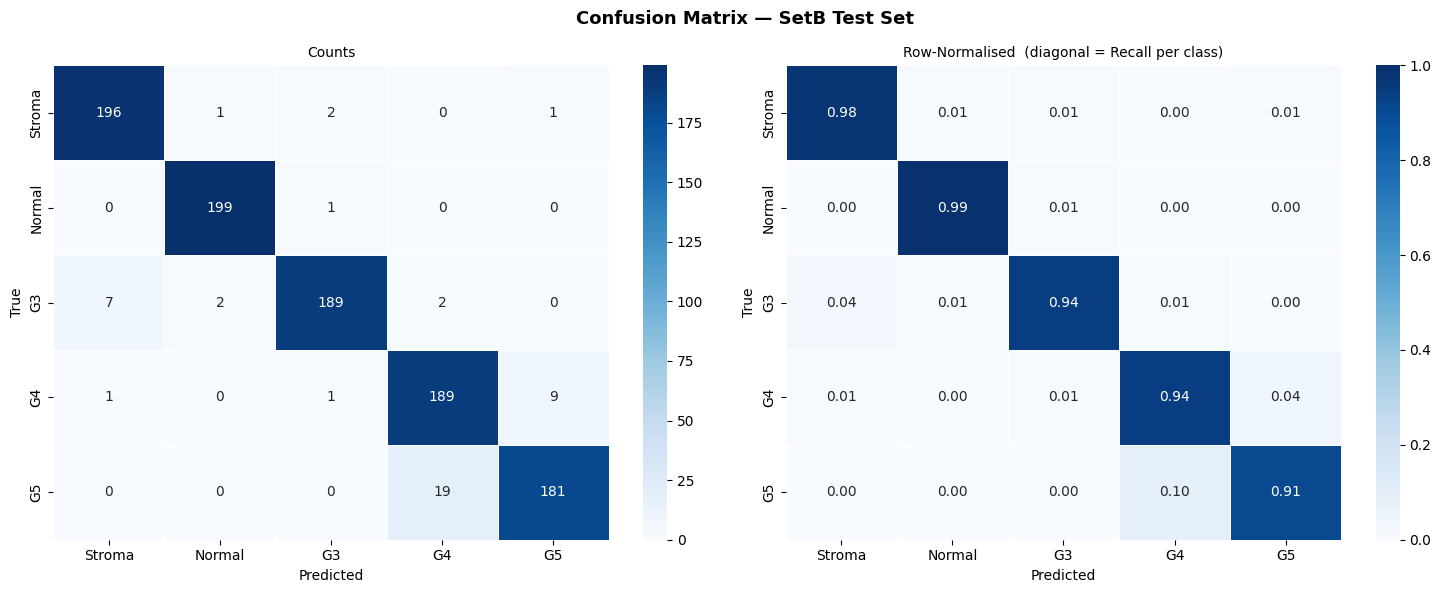

Saved → outputs/setb/reports/confusion_matrix.png


In [20]:
# ── Confusion matrices ────────────────────────────────────────────────────────
cm      = confusion_matrix(all_labels, all_preds, labels=list(range(5)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    f'Confusion Matrix — Set{CONFIG["domain"]} Test Set',
    fontsize=13, fontweight='bold',
)

for ax, data, fmt, title, vmax in zip(
    axes,
    [cm,   cm_norm],
    ['d',  '.2f'],
    ['Counts', 'Row-Normalised  (diagonal = Recall per class)'],
    [None, 1.0],
):
    sns.heatmap(
        data,
        annot=True, fmt=fmt, cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=ax, linewidths=0.4, vmin=0, vmax=vmax,
    )
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)
    ax.set_title(title, fontsize=10)

plt.tight_layout()
cm_path = os.path.join(CONFIG['output_dir'], 'reports', 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {cm_path}')

In [21]:
# ── Confidence analysis ────────────────────────────────────────────────────────
# max-softmax probability is used as a proxy for the model's confidence in its
# prediction.  We split by correct vs incorrect predictions within each class.

max_probs    = all_probs.max(axis=1)
correct_mask = all_preds == all_labels

conf_rows = []
for c, name in enumerate(CLASS_NAMES):
    cls_mask   = all_labels == c
    right      = max_probs[cls_mask &  correct_mask]
    wrong      = max_probs[cls_mask & ~correct_mask]
    conf_rows.append({
        'Class'         : name,
        'N_correct'     : int(correct_mask[cls_mask].sum()),
        'N_errors'      : int((~correct_mask[cls_mask]).sum()),
        'Conf(correct)' : round(right.mean(), 4) if len(right) > 0 else float('nan'),
        'Conf(wrong)'   : round(wrong.mean(), 4) if len(wrong) > 0 else float('nan'),
        'Spec_flag'     : '  ⚠ spec < 0.90' if specificity_p[c] < 0.90 else '',
    })

conf_df = pd.DataFrame(conf_rows).set_index('Class')
print('Confidence & Error Summary')
print('─' * 65)
print(conf_df.to_string())
print('\n⚠ = class specificity below 0.90 — model is over-predicting this class.')

Confidence & Error Summary
─────────────────────────────────────────────────────────────────
        N_correct  N_errors  Conf(correct)  Conf(wrong) Spec_flag
Class                                                            
Stroma        196         4         0.9912       0.8593          
Normal        199         1         0.9957       0.6427          
G3            189        11         0.9909       0.9039          
G4            189        11         0.9905       0.7899          
G5            181        19         0.9809       0.8905          

⚠ = class specificity below 0.90 — model is over-predicting this class.


In [22]:
# ── Top confused class pairs ───────────────────────────────────────────────────
off_diag = []
for t in range(CONFIG['num_classes']):
    for p in range(CONFIG['num_classes']):
        if t != p and cm[t, p] > 0:
            off_diag.append({
                'True'     : CLASS_NAMES[t],
                'Predicted': CLASS_NAMES[p],
                'Count'    : int(cm[t, p]),
                'Rate'     : round(float(cm_norm[t, p]), 3),
            })

confused_df = (
    pd.DataFrame(off_diag)
    .sort_values('Count', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print('Top confused class pairs (off-diagonal, sorted by count):')
print(confused_df.to_string(index=False))
print()
print('Note: G3↔G4 confusion is clinically expected — glandular differentiation')
print('      is a continuous biological spectrum; borders between grades are fuzzy.')
print('Stroma↔Normal confusion at high rates would indicate a preprocessing error.')

Top confused class pairs (off-diagonal, sorted by count):
  True Predicted  Count  Rate
    G5        G4     19 0.095
    G4        G5      9 0.045
    G3    Stroma      7 0.035
Stroma        G3      2 0.010
    G3    Normal      2 0.010
    G3        G4      2 0.010
Stroma    Normal      1 0.005
Stroma        G5      1 0.005
Normal        G3      1 0.005
    G4    Stroma      1 0.005

Note: G3↔G4 confusion is clinically expected — glandular differentiation
      is a continuous biological spectrum; borders between grades are fuzzy.
Stroma↔Normal confusion at high rates would indicate a preprocessing error.


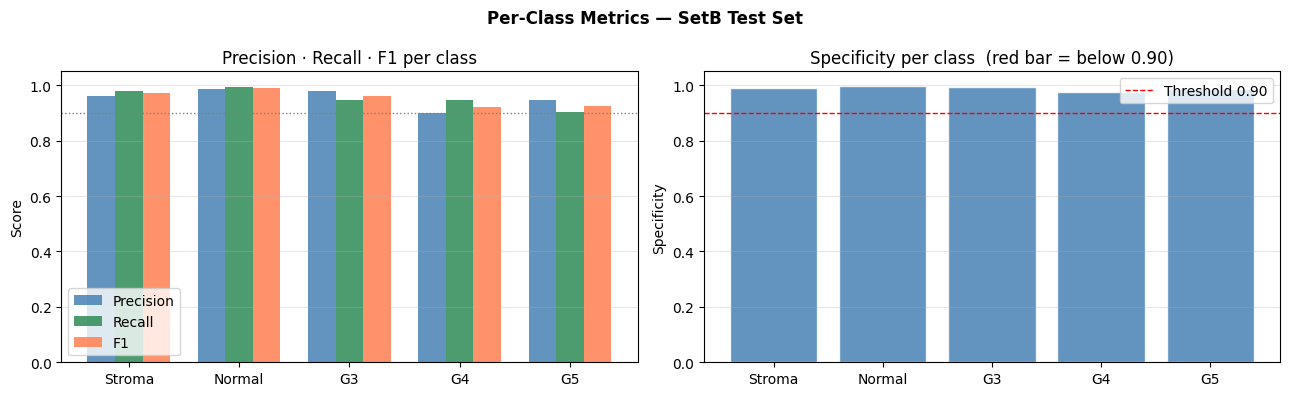

Saved → outputs/setb/reports/per_class_metrics.png


In [23]:
# ── Per-class specificity bar chart ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    f'Per-Class Metrics — Set{CONFIG["domain"]} Test Set',
    fontsize=12, fontweight='bold',
)

x = np.arange(len(CLASS_NAMES))
width = 0.25

# Precision / Recall / F1
ax = axes[0]
ax.bar(x - width, precision_p, width, label='Precision', color='steelblue',  alpha=0.85)
ax.bar(x,         recall_p,    width, label='Recall',    color='seagreen',   alpha=0.85)
ax.bar(x + width, f1_p,        width, label='F1',        color='coral',      alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Precision · Recall · F1 per class')
ax.legend()
ax.axhline(0.9, linestyle=':', color='grey', linewidth=1)
ax.grid(axis='y', alpha=0.3)

# Specificity
ax = axes[1]
colours = ['coral' if s < 0.90 else 'steelblue' for s in specificity_p]
ax.bar(CLASS_NAMES, specificity_p, color=colours, alpha=0.85, edgecolor='white')
ax.axhline(0.90, linestyle='--', color='red', linewidth=1, label='Threshold 0.90')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Specificity')
ax.set_title('Specificity per class  (red bar = below 0.90)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
spec_path = os.path.join(CONFIG['output_dir'], 'reports', 'per_class_metrics.png')
plt.savefig(spec_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {spec_path}')

## 13 · Save Final Report

Write metrics to text file; list all saved artefacts.

In [24]:
report_path = os.path.join(CONFIG['output_dir'], 'reports', 'metrics_report.txt')

lines = [
    f'Phase I Report — Set{CONFIG["domain"]}',
    '=' * 60,
    '',
    'Split Summary',
    '-' * 40,
    (
        index_df
        .groupby(['split', 'class_name'])
        .size()
        .unstack(fill_value=0)
        [CLASS_NAMES]
        .reindex(['train', 'val', 'test'])
        .to_string()
    ),
    '',
    'Class Weights Used',
    '-' * 40,
    '  ' + '  '.join(f'{n}: {w:.4f}' for n, w in zip(CLASS_NAMES, class_weights.tolist())),
    '',
    'Per-Class Test Metrics',
    '-' * 40,
    results_df.to_string(),
    '',
    f'Overall Accuracy : {accuracy:.4f}',
    f'Macro F1         : {macro_f1:.4f}',
    f'Weighted F1      : {weighted_f1:.4f}',
    '',
    'Majority-Class Baseline (lower bound)',
    '-' * 40,
    f'Baseline Accuracy : {majority_acc:.4f}',
    f'Baseline Macro F1 : {majority_f1:.4f}',
    f'Model improvement : Acc +{accuracy - majority_acc:.4f}  Macro F1 +{macro_f1 - majority_f1:.4f}',
    '',
    'Confidence & Error Summary',
    '-' * 40,
    conf_df.to_string(),
    '',
    'Top Confused Pairs',
    '-' * 40,
    confused_df.to_string(index=False),
    '',
    'Training Info',
    '-' * 40,
    f'Best epoch       : {ckpt["epoch"]}',
    f'Best Val F1      : {ckpt["val_macro_f1"]:.4f}',
    f'Checkpoint       : {ckpt_path}',
]

with open(report_path, 'w') as fh:
    fh.write('\n'.join(lines))

print(f'Report saved → {report_path}\n')

# ── Full artifact listing ─────────────────────────────────────────────────────
print(f'Phase I artifacts for Set{CONFIG["domain"]}:')
for root, dirs, files in os.walk(CONFIG['output_dir']):
    dirs.sort()
    for fname in sorted(files):
        full = os.path.join(root, fname)
        size = os.path.getsize(full)
        size_str = f'{size/1024:.1f} KB' if size < 1_000_000 else f'{size/1_000_000:.1f} MB'
        print(f'  {full}  ({size_str})')

Report saved → outputs/setb/reports/metrics_report.txt

Phase I artifacts for SetB:
  outputs/setb/checkpoints/best_model.pth  (31.3 MB)
  outputs/setb/logs/training_log.csv  (1.5 KB)
  outputs/setb/reports/confusion_matrix.png  (79.9 KB)
  outputs/setb/reports/metrics_report.txt  (2.1 KB)
  outputs/setb/reports/per_class_metrics.png  (52.0 KB)
  outputs/setb/reports/training_curves.png  (110.1 KB)
  outputs/setb/splits/index_B.csv  (364.3 KB)


In [25]:
# ── Final summary print ────────────────────────────────────────────────────────
print('┌' + '─' * 52 + '┐')
print(f'│  Phase I Complete — Set{CONFIG["domain"]}' + ' ' * (28 - len(CONFIG['domain'])) + '│')
print('├' + '─' * 52 + '┤')
print(f'│  Best epoch      {ckpt["epoch"]:>4d}' + ' ' * 30 + '│')
print(f'│  Val Macro F1    {ckpt["val_macro_f1"]:>8.4f}' + ' ' * 26 + '│')
print(f'│  Test Macro F1   {macro_f1:>8.4f}' + ' ' * 26 + '│')
print(f'│  Test Accuracy   {accuracy:>8.4f}' + ' ' * 26 + '│')
print(f'│  Test Weighted F1 {weighted_f1:>7.4f}' + ' ' * 25 + '│')
print('└' + '─' * 52 + '┘')
print()
print('To run SetB: change CONFIG["domain"] = \'B\' and restart kernel.')

┌────────────────────────────────────────────────────┐
│  Phase I Complete — SetB                           │
├────────────────────────────────────────────────────┤
│  Best epoch        21                              │
│  Val Macro F1      0.9568                          │
│  Test Macro F1     0.9540                          │
│  Test Accuracy     0.9540                          │
│  Test Weighted F1  0.9540                         │
└────────────────────────────────────────────────────┘

To run SetB: change CONFIG["domain"] = 'B' and restart kernel.
